# Смена директории

In [3]:
%cd ..

/Users/macbook/Desktop/Project/Year_project


# Импорт библиотек

In [57]:
import logging
import warnings
import time


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import yaml
import joblib
import shap
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from category_encoders import CatBoostEncoder
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from utils.dev_utils import get_pool
from utils.pipeline_utils import CustomPreprocessor
from utils.metrics import MetricCalculator, metric_funcs
from utils.style.styler import style_metrics
from utils.style.html_output import print_multiple_html
from utils.plot_utils import plot_gini_by_period_styled, plot_roc_by_masks

In [58]:
logging.getLogger().setLevel(logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_palette('bright')


pd.options.display.float_format = "{:.2f}".format
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100

In [59]:
%load_ext autoreload
%autoreload 2
%aimport utils.plot_utils
%aimport utils.eda_utils
%aimport utils.style_utils
%aimport utils.psi
%aimport utils.style.styler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Входные данные

## Загрузка данных

In [81]:
data = pd.read_parquet('./data/processed/data.pqt')

data.shape

(1097231, 494)

## Валидные переменные

In [82]:
path = r'./docs/valid_features.xlsx'
valid_features_data = pd.read_excel(path, index_col=False)

## Конфиги/константы

In [83]:
TARGET = 'target'
DATE_MONTH = 'date_month'
DATE_QUARTAL = 'date_quartal'

FEATURES = valid_features_data.loc[(valid_features_data['valid_flag'] == 1)]['attribute'].values
CAT_FEATURES = list(set(FEATURES) & set(data.select_dtypes(include=["object", "category"]).columns))
NUM_FEATURES = list(set(FEATURES) & set(data.select_dtypes(include=["number"]).columns))

TRAIN_MASK = (data['sample_type'] == 'TRAIN')
TEST_MASK = (data['sample_type'] == 'TEST')
OOT_MASK = (data['sample_type'] == 'OOT')

DEV_MASK = (data['competition_sample_type'] == 'TRAIN')

In [84]:
print_multiple_html(
    ('Кол-во переменных: ', len(FEATURES)),
    ('Кол-во категориальных переменных: ', len(CAT_FEATURES))
)

In [64]:
metr_funcs = {
    'roc_auc': metric_funcs.roc_auc_score_nan,
    'gini': metric_funcs.gini_score_nan,
    'precision': metric_funcs.precision,
    'recall': metric_funcs.recall
}

stats_funcs = {
    'obs_cnt': lambda y_true, data: len(y_true),
    'target_cnt': lambda y_true, data: sum(y_true),
    'DR': lambda y_true, data: sum(y_true) / len(y_true)
}

# Класс для расчета метрик
metr_calc = MetricCalculator(metr_funcs=metr_funcs, stats_funcs=stats_funcs)


STYLE_CONFIG = {
    'percent_cols': ['gini', 'roc_auc', 'DR', 'precision', 'recall'],
    'int_cols': ['obs_cnt', 'target_cnt'],
    'gradient_cols': ['gini', 'roc_auc', 'precision', 'recall'],
    'gradient_cmap': 'RdYlGn',
}

# Словарь для сохранения времени обучения моделей
train_timing = {}

In [65]:
def metrics_split(data, group_cols, metr_calc, pred_cols=['lg_model_preds'], target='target', asc=True):
    """Упрощенный интерфес для расчета метрик"""

    metr_split = metr_calc.calculate(data, true_col=target, pred_cols=pred_cols, group_cols=group_cols)
    metr_split = (
        metr_split
        .sort_values(by=group_cols, ascending=asc)
        .set_index(group_cols)
    )
    
    return metr_split

# Обучение  Random Forest

In [ ]:
default_params = {
    'n_estimators': 100,
    'criterion': 'gini',
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'min_weight_fraction_leaf': 0.0,
    'max_features': 'sqrt',
    'max_leaf_nodes': None,
    'min_impurity_decrease': 0.0,
    'class_weight': None,
    'ccp_alpha': 0.0,
    'max_samples': None,
    'random_state': 42,
    'n_jobs':-1
}


preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), NUM_FEATURES),
        ('cat', CatBoostEncoder(), CAT_FEATURES),
    ], 
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(**default_params))
])

pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])

In [69]:
data['rf_model_preds'] = pipeline.predict_proba(data[FEATURES])[:, 1]

In [70]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='rf_model_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,rf_model_preds,99.1%,98.2%,99.4%,66.8%,350 849,12 166,3.5%
TEST,rf_model_preds,91.1%,82.2%,93.1%,41.9%,150 365,5 383,3.6%
OOT,rf_model_preds,88.5%,77.1%,83.7%,32.9%,89 326,3 114,3.5%


## Подбор гиперпараметров для Random Forest

In [71]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 30, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None, 0.3, 0.5, 0.7]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state': 42,
        'n_jobs': -1
        }

    pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(**params))
    ])

    pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])
    
    
    roc_auc = roc_auc_score(data[TEST_MASK][TARGET], pipeline.predict_proba(data[TEST_MASK][FEATURES])[:, 1])
    return roc_auc

In [72]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=False)

[I 2026-03-31 22:36:50,611] A new study created in memory with name: no-name-670de396-4809-40d6-b2bf-65a29ec8cada
[I 2026-03-31 22:38:41,444] Trial 0 finished with value: 0.9329839091685767 and parameters: {'n_estimators': 150, 'max_depth': 27, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.3, 'criterion': 'entropy', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9329839091685767.
[I 2026-03-31 22:40:50,534] Trial 1 finished with value: 0.8802211779751308 and parameters: {'n_estimators': 150, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 0.7, 'criterion': 'entropy', 'bootstrap': True, 'class_weight': None}. Best is trial 0 with value: 0.9329839091685767.
[I 2026-03-31 22:44:02,315] Trial 2 finished with value: 0.7909306897682414 and parameters: {'n_estimators': 50, 'max_depth': 27, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': None, 'criterion': 'entropy', 'bootstrap': False, 'class_we

In [ ]:
final_params_rf_model = {**default_params, **study.best_params}
final_params_rf_model

{'n_estimators': 200,
 'criterion': 'gini',
 'max_depth': 30,
 'min_samples_split': 17,
 'min_samples_leaf': 7,
 'min_weight_fraction_leaf': 0.0,
 'max_features': 0.3,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'class_weight': 'balanced',
 'ccp_alpha': 0.0,
 'max_samples': None,
 'random_state': 42,
 'n_jobs': -1,
 'bootstrap': False}

## Финальная модель RandomForestClassifier

In [178]:
# Обучение модели с подобранными гиперпараметрами
final_model_start_time = time.time()
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(**final_params_rf_model))
])

pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])
final_model_train_time = time.time() - final_model_start_time
train_timing['Random_Forest'] = final_model_train_time

data['rf_model_optuna_preds'] = pipeline.predict_proba(data[FEATURES])[:, 1]

In [195]:
# Метрики модели с подобранными гиперпараметрами
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='rf_model_optuna_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,rf_model_optuna_preds,98.9%,97.7%,76.5%,84.0%,350 849,12 166,3.5%
TEST,rf_model_optuna_preds,93.6%,87.2%,64.9%,60.2%,150 365,5 383,3.6%
OOT,rf_model_optuna_preds,90.9%,81.9%,58.1%,45.6%,89 326,3 114,3.5%


In [205]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='rf_model_optuna_preds',
    group_cols=DATE_MONTH,
    metr_calc=metr_calc,
    asc=True
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
date_month,,,,,,,,
2020-01,rf_model_optuna_preds,95.7%,91.5%,56.3%,67.7%,134 339,3 401,2.5%
2020-02,rf_model_optuna_preds,96.5%,93.0%,73.8%,72.3%,86 467,3 469,4.0%
2020-03,rf_model_optuna_preds,98.2%,96.3%,79.3%,81.5%,95 121,3 832,4.0%
2020-04,rf_model_optuna_preds,97.7%,95.5%,79.4%,78.2%,98 615,3 898,4.0%
2020-05,rf_model_optuna_preds,98.3%,96.7%,80.3%,84.0%,86 672,2 949,3.4%
2020-06,rf_model_optuna_preds,91.0%,81.9%,58.1%,45.5%,86 572,2 995,3.5%
2020-07,rf_model_optuna_preds,90.5%,81.0%,58.5%,46.2%,2 754,119,4.3%


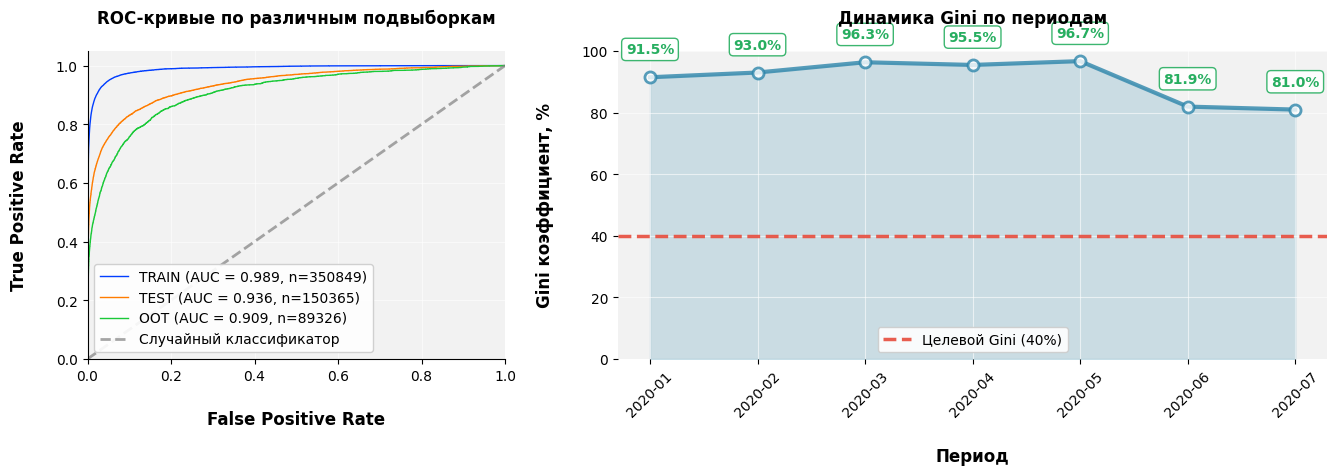

In [206]:
# Графики распределения таргета по выборкам
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [1, 1.7]})
masks_dict = {'TRAIN': TRAIN_MASK, 'TEST': TEST_MASK, 'OOT': OOT_MASK}

ax = axes[0]
plot_roc_by_masks(data, TARGET, 'rf_model_optuna_preds', masks_dict, 
                     figsize=(8, 4), palette='bright', 
                     title='ROC-кривые по различным подвыборкам',
                     ax=ax)

ax = axes[1]
plot_gini_by_period_styled(metr_split.reset_index(), 'gini', DATE_MONTH,
                              figsize=(8, 4), 
                              target_gini=40,
                              title='Динамика Gini по периодам',
                              ax=ax)
                              

In [197]:
gini_rf = metr_split['gini']
roc_auc_rf  = metr_split['roc_auc']
precision_rf = metr_split['precision']
recall_rf = metr_split['recall']

# Обучение Lightgbm

In [ ]:
default_params = {
        'objective':'binary',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'max_depth': -1,
        'learning_rate': 0.05,
        'n_estimators': 200,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.001,
        'reg_lambda': 0.001, 
        'n_jobs': -1,
        'random_state': 42,
        'verbose': -1,
        'random_state': 42
}

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), NUM_FEATURES),
        ('cat', CatBoostEncoder(), CAT_FEATURES),
    ], 
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(**default_params))
])


pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [100]:
data['lgbm_model_preds'] = pipeline.predict_proba(data[FEATURES])[:, 1]

In [101]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='lgbm_model_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,lgbm_model_preds,93.5%,87.1%,90.4%,46.0%,350 849,12 166,3.5%
TEST,lgbm_model_preds,92.1%,84.1%,88.4%,43.7%,150 365,5 383,3.6%
OOT,lgbm_model_preds,90.3%,80.6%,78.8%,34.3%,89 326,3 114,3.5%


## Подбор гиперпараметров для LGBM

In [102]:
def objective(trial):
    params = {
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': 20,
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'is_unbalance': trial.suggest_categorical('is_unbalance', [True, False]),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
        }

    pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(**params))
    ])

    pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])
    
    
    roc_auc = roc_auc_score(data[TEST_MASK][TARGET], pipeline.predict_proba(data[TEST_MASK][FEATURES])[:, 1])
    return roc_auc

In [103]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=False)

[I 2026-04-01 01:12:28,859] A new study created in memory with name: no-name-0e2760b5-aed6-4957-b93d-4191dbfee38b


[I 2026-04-01 01:12:45,315] Trial 0 finished with value: 0.9425031419467876 and parameters: {'n_estimators': 200, 'num_leaves': 96, 'max_depth': 12, 'learning_rate': 0.07661100707771368, 'subsample': 0.5780093202212182, 'reg_alpha': 0.15599452033620265, 'reg_lambda': 0.05808361216819946, 'is_unbalance': True}. Best is trial 0 with value: 0.9425031419467876.
[I 2026-04-01 01:12:59,059] Trial 1 finished with value: 0.9284120840967754 and parameters: {'n_estimators': 400, 'num_leaves': 11, 'max_depth': 15, 'learning_rate': 0.1696753360719655, 'subsample': 0.6061695553391381, 'reg_alpha': 0.18182496720710062, 'reg_lambda': 0.18340450985343382, 'is_unbalance': False}. Best is trial 0 with value: 0.9425031419467876.
[I 2026-04-01 01:13:14,270] Trial 2 finished with value: 0.9094004034959308 and parameters: {'n_estimators': 250, 'num_leaves': 36, 'max_depth': 10, 'learning_rate': 0.01607123851203988, 'subsample': 0.6460723242676091, 'reg_alpha': 0.3663618432936917, 'reg_lambda': 0.45606998421

In [104]:
final_params_lgbm_model = {**default_params, **study.best_params}
final_params_lgbm_model

{'objective': 'binary',
 'boosting_type': 'gbdt',
 'num_leaves': 51,
 'max_depth': 7,
 'learning_rate': 0.1613944926936775,
 'n_estimators': 450,
 'min_child_samples': 20,
 'subsample': 0.8518764420439963,
 'colsample_bytree': 0.8,
 'reg_alpha': 0.9532225797663595,
 'reg_lambda': 0.025779703113711014,
 'n_jobs': -1,
 'random_state': 42,
 'verbose': -1,
 'is_unbalance': False}

## Финальная модель LGBM

In [105]:
# Обучение модели с подобранными гиперпараметрами
final_model_start_time = time.time()
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(**final_params_lgbm_model))
])

pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])
final_model_train_time = time.time() - final_model_start_time
train_timing['lgbm'] = final_model_train_time

data['lgbm_model_optuna_preds'] = pipeline.predict_proba(data[FEATURES])[:, 1]

In [207]:
# Метрики модели с подобранными гиперпараметрами
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='lgbm_model_optuna_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,lgbm_model_optuna_preds,98.1%,96.3%,95.2%,64.2%,350 849,12 166,3.5%
TEST,lgbm_model_optuna_preds,94.7%,89.4%,89.5%,53.5%,150 365,5 383,3.6%
OOT,lgbm_model_optuna_preds,90.6%,81.2%,76.3%,37.5%,89 326,3 114,3.5%


In [208]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='lgbm_model_optuna_preds',
    group_cols=DATE_MONTH,
    metr_calc=metr_calc,
    asc=True
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
date_month,,,,,,,,
2020-01,lgbm_model_optuna_preds,95.8%,91.5%,85.2%,52.7%,134 339,3 401,2.5%
2020-02,lgbm_model_optuna_preds,96.6%,93.1%,93.0%,58.1%,86 467,3 469,4.0%
2020-03,lgbm_model_optuna_preds,97.8%,95.7%,96.2%,65.3%,95 121,3 832,4.0%
2020-04,lgbm_model_optuna_preds,97.2%,94.4%,95.7%,61.4%,98 615,3 898,4.0%
2020-05,lgbm_model_optuna_preds,98.1%,96.2%,97.2%,67.3%,86 672,2 949,3.4%
2020-06,lgbm_model_optuna_preds,90.6%,81.2%,76.4%,37.6%,86 572,2 995,3.5%
2020-07,lgbm_model_optuna_preds,90.7%,81.4%,73.2%,34.5%,2 754,119,4.3%


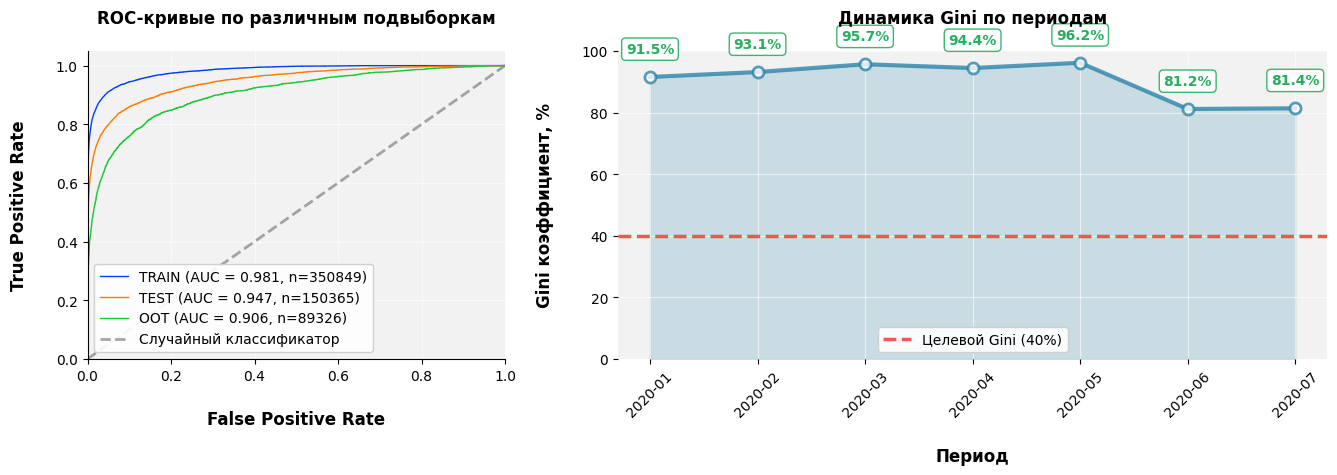

In [209]:
# Графики распределения таргета по выборкам
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [1, 1.7]})
masks_dict = {'TRAIN': TRAIN_MASK, 'TEST': TEST_MASK, 'OOT': OOT_MASK}

ax = axes[0]
plot_roc_by_masks(data, TARGET, 'lgbm_model_optuna_preds', masks_dict, 
                     figsize=(8, 4), palette='bright', 
                     title='ROC-кривые по различным подвыборкам',
                     ax=ax)

ax = axes[1]
plot_gini_by_period_styled(metr_split.reset_index(), 'gini', DATE_MONTH,
                              figsize=(8, 4), 
                              target_gini=40,
                              title='Динамика Gini по периодам',
                              ax=ax)

In [109]:
gini_lgbm = metr_split['gini']
roc_auc_lgbm  = metr_split['roc_auc']
precision_lgbm  = metr_split['precision']
recall_lgbm  = metr_split['recall'] 

# Обучение XGBoost

In [111]:
default_params = {
    'objective': 'binary:logistic',      
    'eval_metric': 'logloss',       
    'scale_pos_weight': 1,              
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1,
    'n_jobs': -1,
    'verbose': -1,
    'random_state': 42
}


preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]), NUM_FEATURES),
        ('cat', CatBoostEncoder(), CAT_FEATURES),
    ], 
    remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**default_params))
])


pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [112]:
data['xgboost_model_preds'] = pipeline.predict_proba(data[FEATURES])[:, 1]

In [113]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='xgboost_model_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,xgboost_model_preds,92.9%,85.8%,90.0%,44.6%,350 849,12 166,3.5%
TEST,xgboost_model_preds,91.5%,82.9%,87.7%,41.9%,150 365,5 383,3.6%
OOT,xgboost_model_preds,90.0%,79.9%,77.6%,33.3%,89 326,3 114,3.5%


## Подбор гиперпараметров для XGBoost

In [114]:
def objective(trial):
    params = {
        'objective': 'binary:logistic',  
        'max_depth': trial.suggest_int('max_depth', 2, 15),
        'subsample': trial.suggest_discrete_uniform('subsample', 0.6, 1.0, 0.05),
        'n_estimators': trial.suggest_int('n_estimators', 50, 1000, 50),
        'eta': trial.suggest_discrete_uniform('eta', 0.01, 0.1, 0.01),
        'reg_alpha': trial.suggest_int('reg_alpha', 1, 50),
        'reg_lambda': trial.suggest_int('reg_lambda', 5, 100),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 20),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.1, 1.0),   
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
        }

    pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**params))
    ])

    pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])
    
    
    roc_auc = roc_auc_score(data[TEST_MASK][TARGET], pipeline.predict_proba(data[TEST_MASK][FEATURES])[:, 1])
    return roc_auc

In [115]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=False)

[I 2026-04-01 01:22:47,053] A new study created in memory with name: no-name-c9217139-35ab-49b9-bb01-ed9e1504440a
[I 2026-04-01 01:23:17,788] Trial 0 finished with value: 0.9381087787376697 and parameters: {'max_depth': 7, 'subsample': 1.0, 'n_estimators': 750, 'eta': 0.060000000000000005, 'reg_alpha': 8, 'reg_lambda': 19, 'min_child_weight': 3, 'colsample_bytree': 0.8795585311974417}. Best is trial 0 with value: 0.9381087787376697.
[I 2026-04-01 01:23:30,455] Trial 1 finished with value: 0.8941211092017078 and parameters: {'max_depth': 10, 'subsample': 0.9, 'n_estimators': 50, 'eta': 0.09999999999999999, 'reg_alpha': 42, 'reg_lambda': 25, 'min_child_weight': 5, 'colsample_bytree': 0.2650640588680904}. Best is trial 0 with value: 0.9381087787376697.
[I 2026-04-01 01:23:54,865] Trial 2 finished with value: 0.9056442247836628 and parameters: {'max_depth': 6, 'subsample': 0.8, 'n_estimators': 450, 'eta': 0.03, 'reg_alpha': 31, 'reg_lambda': 18, 'min_child_weight': 7, 'colsample_bytree': 0

In [119]:
final_params_xgboost_model = {**default_params, **study.best_params}
final_params_xgboost_model

{'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'scale_pos_weight': 1,
 'n_estimators': 700,
 'max_depth': 15,
 'learning_rate': 0.1,
 'subsample': 1.0,
 'colsample_bytree': 0.7679731169109003,
 'reg_alpha': 9,
 'reg_lambda': 42,
 'n_jobs': -1,
 'verbose': -1,
 'random_state': 42,
 'eta': 0.060000000000000005,
 'min_child_weight': 2}

## Финальная модель XGBoost

In [120]:
# Обучение модели с подобранными гиперпараметрами
final_model_start_time = time.time()
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**final_params_xgboost_model))
])

pipeline.fit(data.loc[TRAIN_MASK][FEATURES], data.loc[TRAIN_MASK][TARGET])
final_model_train_time = time.time() - final_model_start_time
train_timing['xgboost'] = final_model_train_time

data['xgboost_model_optuna_preds'] = pipeline.predict_proba(data[FEATURES])[:, 1]

In [210]:
# Метрики модели с подобранными гиперпараметрами
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='xgboost_model_optuna_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,xgboost_model_optuna_preds,98.8%,97.7%,96.0%,68.5%,350 849,12 166,3.5%
TEST,xgboost_model_optuna_preds,94.9%,89.8%,90.4%,53.6%,150 365,5 383,3.6%
OOT,xgboost_model_optuna_preds,91.4%,82.7%,81.3%,38.0%,89 326,3 114,3.5%


In [122]:
gini_xgboost = metr_split['gini']
roc_auc_xgboost  = metr_split['roc_auc']
precision_xgboost  = metr_split['precision']
recall_xgboost  = metr_split['recall'] 

In [211]:
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='xgboost_model_optuna_preds',
    group_cols=DATE_MONTH,
    metr_calc=metr_calc,
    asc=True
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
date_month,,,,,,,,
2020-01,xgboost_model_optuna_preds,96.3%,92.7%,86.0%,54.3%,134 339,3 401,2.5%
2020-02,xgboost_model_optuna_preds,96.9%,93.8%,93.8%,59.4%,86 467,3 469,4.0%
2020-03,xgboost_model_optuna_preds,98.3%,96.6%,96.5%,67.1%,95 121,3 832,4.0%
2020-04,xgboost_model_optuna_preds,98.0%,96.0%,97.0%,65.8%,98 615,3 898,4.0%
2020-05,xgboost_model_optuna_preds,98.6%,97.2%,98.1%,73.8%,86 672,2 949,3.4%
2020-06,xgboost_model_optuna_preds,91.4%,82.8%,81.4%,38.0%,86 572,2 995,3.5%
2020-07,xgboost_model_optuna_preds,90.9%,81.8%,78.2%,36.1%,2 754,119,4.3%


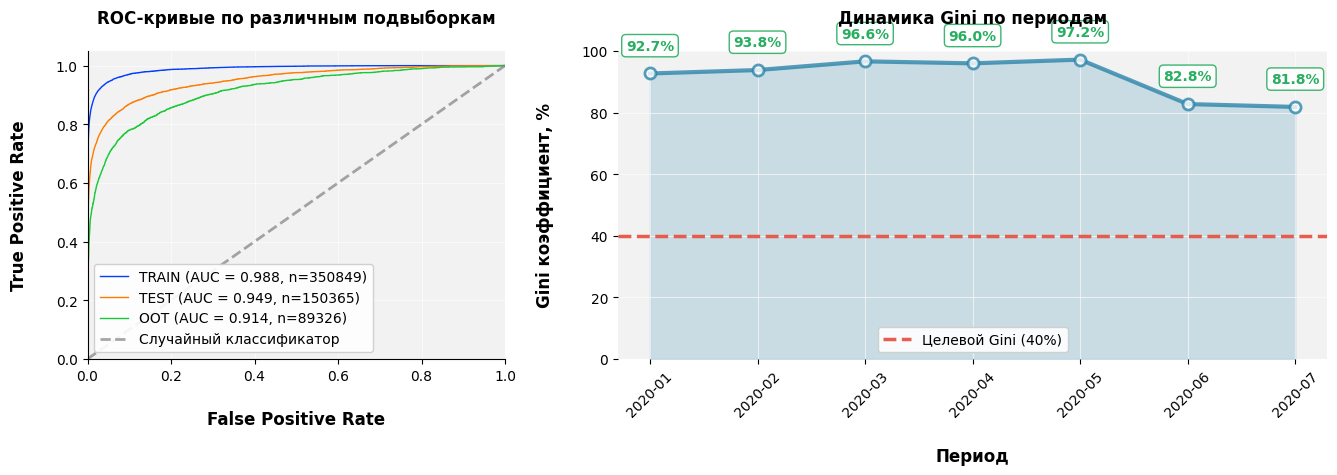

In [212]:
# Графики распределения таргета по выборкам
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [1, 1.7]})
masks_dict = {'TRAIN': TRAIN_MASK, 'TEST': TEST_MASK, 'OOT': OOT_MASK}

ax = axes[0]
plot_roc_by_masks(data, TARGET, 'xgboost_model_optuna_preds', masks_dict, 
                     figsize=(8, 4), palette='bright', 
                     title='ROC-кривые по различным подвыборкам',
                     ax=ax)

ax = axes[1]
plot_gini_by_period_styled(metr_split.reset_index(), 'gini', DATE_MONTH,
                              figsize=(8, 4), 
                              target_gini=40,
                              title='Динамика Gini по периодам',
                              ax=ax)

# Обучение CatBoost

In [124]:
# Берем только наблюдения с взаимной целевой и преобразуем кат. фичи
dev_sample = data.loc[DEV_MASK].copy()

# Трансформируем категориальные переменные
dev_sample = CustomPreprocessor(cat_features=CAT_FEATURES).transform(dev_sample)

In [125]:
train_pool = get_pool(dev_sample, TARGET, TRAIN_MASK, FEATURES, CAT_FEATURES)
test_pool = get_pool(dev_sample, TARGET, TEST_MASK, FEATURES, CAT_FEATURES)
oot_pool = get_pool(dev_sample, TARGET, OOT_MASK, FEATURES, CAT_FEATURES)

In [126]:
# Параметры модели
default_params = {
    "iterations": 100,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "early_stopping_rounds": 20,
    "verbose": 0,
    "random_seed": 42,
}

In [127]:
# Обучение модели
model = CatBoostClassifier(**default_params, cat_features=CAT_FEATURES)
model.fit(train_pool, eval_set=test_pool, use_best_model=True, plot=False)

In [128]:
# Предсказания для всего набора
pipeline = Pipeline([
    ('preprocessor', CustomPreprocessor(cat_features=CAT_FEATURES)),
    ('model', model),
])

data['cb_model_preds'] = pipeline.predict_proba(data[FEATURES])[:, 1]

## Метрики

In [129]:
# По сэмплам
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='cb_model_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,cb_model_preds,91.7%,83.4%,93.7%,46.1%,350 849,12 166,3.5%
TEST,cb_model_preds,90.9%,81.8%,91.1%,43.4%,150 365,5 383,3.6%
OOT,cb_model_preds,88.5%,76.9%,65.4%,34.5%,89 326,3 114,3.5%


In [130]:
# По месяцам
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='cb_model_preds',
    group_cols=DATE_MONTH,
    metr_calc=metr_calc,
    asc=True
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
date_month,,,,,,,,
2020-01,cb_model_preds,91.1%,82.1%,87.8%,42.6%,134 339,3 401,2.5%
2020-02,cb_model_preds,91.9%,83.7%,94.9%,45.8%,86 467,3 469,4.0%
2020-03,cb_model_preds,92.1%,84.1%,94.7%,51.5%,95 121,3 832,4.0%
2020-04,cb_model_preds,91.1%,82.2%,93.6%,43.5%,98 615,3 898,4.0%
2020-05,cb_model_preds,91.1%,82.3%,92.8%,41.8%,86 672,2 949,3.4%
2020-06,cb_model_preds,88.4%,76.8%,65.4%,34.4%,86 572,2 995,3.5%
2020-07,cb_model_preds,89.9%,79.7%,66.2%,37.8%,2 754,119,4.3%


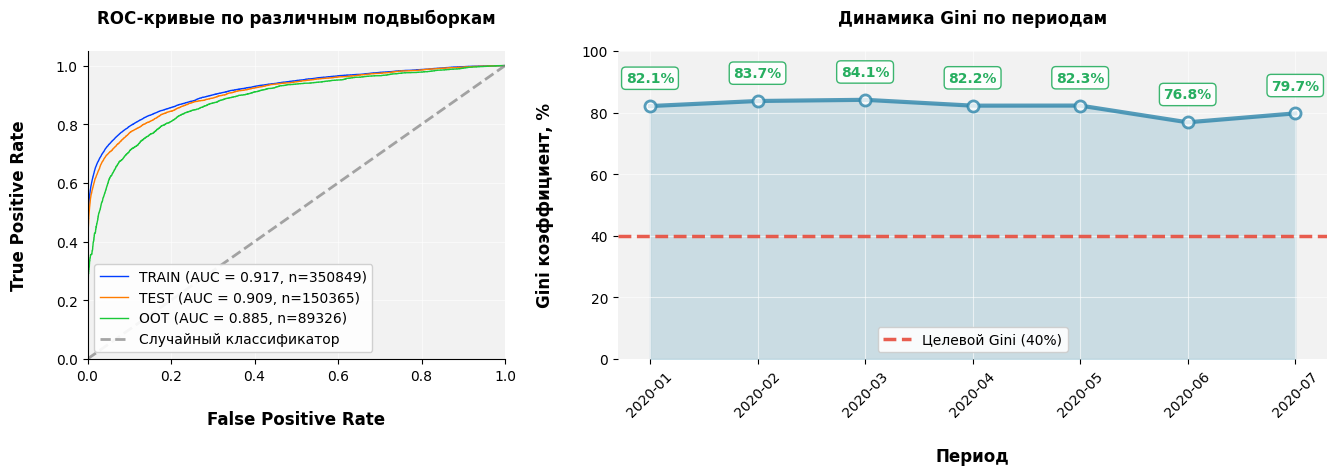

In [131]:
# Графики распределения таргета по выборкам
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [1, 1.7]})
masks_dict = {'TRAIN': TRAIN_MASK, 'TEST': TEST_MASK, 'OOT': OOT_MASK}

ax = axes[0]
plot_roc_by_masks(data, TARGET, 'cb_model_preds', masks_dict, 
                     figsize=(8, 4), palette='bright', 
                     title='ROC-кривые по различным подвыборкам',
                     ax=ax)

ax = axes[1]
plot_gini_by_period_styled(metr_split.reset_index(), 'gini', DATE_MONTH,
                              figsize=(8, 4), 
                              target_gini=40,
                              title='Динамика Gini по периодам',
                              ax=ax)

# Отбор переменных

In [132]:
importances_df = pd.DataFrame({
    'Feature': model.feature_names_,
    'Importance': model.get_feature_importance()
}).sort_values('Importance', ascending=False)

importances_df.head(8)

,Feature,Importance
24,C13,5.46
319,V294,3.69
7,card6,3.57
13,C1,3.56
3,card2,3.38
25,C14,3.24
131,V91,3.22
0,TransactionAmt,2.89


In [133]:
# Далее используем важные переменные
IMP_SHORT_FEATURES = importances_df[importances_df['Importance'] > 0.01]['Feature'].to_list()
IMP_CAT_FEATURES = [i for i in CAT_FEATURES if i in IMP_SHORT_FEATURES]

print_multiple_html(
    (f"Кол-во важных фичей (total): ", len(IMP_SHORT_FEATURES)),
    (f"Кол-во важных категориальных фичей: ", len(IMP_CAT_FEATURES)),
)

In [134]:
# Для простоты берем топ-30
FINAL_FEATURES = importances_df.loc[importances_df['Feature'].isin(IMP_SHORT_FEATURES)][:30]['Feature'].to_list()
FINAL_CAT_FEATURES = [i for i in IMP_CAT_FEATURES if i in FINAL_FEATURES]

In [135]:
print_multiple_html(
    (f"Кол-во финальных фичей: ", len(FINAL_FEATURES)),
    (f"Кол-во финальных категориальных фичей: ", len(FINAL_CAT_FEATURES)),
)

In [136]:
# Сохраняем переменные
features = {
    'FINAL_FEATURES': FINAL_FEATURES,
    'FINAL_CAT_FEATURES': FINAL_CAT_FEATURES
}

with open(r'./models/params/features.yaml', 'w', encoding='utf-8') as file:
    yaml.dump(features, file, allow_unicode=True, default_flow_style=False)

# Подбор гиперпараметров


In [137]:
# Обновляем пулы данных
train_pool = get_pool(dev_sample, TARGET, TRAIN_MASK, FINAL_FEATURES, FINAL_CAT_FEATURES)
test_pool = get_pool(dev_sample, TARGET, TEST_MASK, FINAL_FEATURES, FINAL_CAT_FEATURES)
oot_pool = get_pool(dev_sample, TARGET, OOT_MASK, FINAL_FEATURES, FINAL_CAT_FEATURES)

In [138]:
def objective(trial):
    params = {
        'iterations':trial.suggest_int("iterations", 100, 500),                                # Количество деревьев в бустинге
        'depth': trial.suggest_int('depth', 4, 7),                                             # Глубина деревьев
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),            # Скорость обучения
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1),              # Выборка признаков на каждом уровне дерева 
        'verbose': False,
        'random_state': 42
    }

    catboost = CatBoostClassifier(**params)
    catboost.fit(train_pool, plot=False)
    
    roc_auc = roc_auc_score(data[TEST_MASK][TARGET], catboost.predict_proba(test_pool)[:, 1])
    return roc_auc


In [139]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=10, show_progress_bar=False)

[I 2026-04-01 01:47:11,318] A new study created in memory with name: no-name-0120f359-c9b6-45b6-b488-4a09841b8852
[I 2026-04-01 01:47:20,188] Trial 0 finished with value: 0.9048330714133531 and parameters: {'iterations': 250, 'depth': 7, 'learning_rate': 0.1205712628744377, 'colsample_bylevel': 0.0638792635777333}. Best is trial 0 with value: 0.9048330714133531.
[I 2026-04-01 01:47:24,585] Trial 1 finished with value: 0.8392748508361533 and parameters: {'iterations': 162, 'depth': 4, 'learning_rate': 0.012184186502221764, 'colsample_bylevel': 0.08795585311974417}. Best is trial 0 with value: 0.9048330714133531.
[I 2026-04-01 01:47:36,723] Trial 2 finished with value: 0.8683154176995044 and parameters: {'iterations': 341, 'depth': 6, 'learning_rate': 0.010725209743171997, 'colsample_bylevel': 0.0972918866945795}. Best is trial 0 with value: 0.9048330714133531.
[I 2026-04-01 01:47:46,247] Trial 3 finished with value: 0.8428459053228239 and parameters: {'iterations': 433, 'depth': 4, 'lea

In [140]:
final_params = {**default_params, **study.best_params}
final_params

{'iterations': 250,
 'loss_function': 'Logloss',
 'eval_metric': 'AUC',
 'early_stopping_rounds': 20,
 'verbose': 0,
 'random_seed': 42,
 'depth': 7,
 'learning_rate': 0.1205712628744377,
 'colsample_bylevel': 0.0638792635777333}

In [141]:
# Сохраняем параметры
with open(r'./models/params/best_params.yaml', 'w', encoding='utf-8') as file:
    yaml.dump(final_params, file)

## Финальная модель Catboost

In [142]:
# Создаем пулы данных
train_pool = get_pool(dev_sample, TARGET, TRAIN_MASK, FINAL_FEATURES, FINAL_CAT_FEATURES)
test_pool = get_pool(dev_sample, TARGET, TEST_MASK, FINAL_FEATURES, FINAL_CAT_FEATURES)
oot_pool = get_pool(dev_sample, TARGET, OOT_MASK, FINAL_FEATURES, FINAL_CAT_FEATURES)

In [143]:
# Создаем и обучаем модель
final_model_start_time = time.time()

final_model = CatBoostClassifier(**final_params, cat_features=FINAL_CAT_FEATURES)
final_model.fit(train_pool, eval_set=test_pool)

final_model_train_time = time.time() - final_model_start_time
train_timing['Catboost'] = final_model_train_time

In [144]:
# Предсказания для dev_sample
dev_sample['final_model_preds'] = final_model.predict_proba(dev_sample[FINAL_FEATURES])[:, 1]

In [145]:
# # Предсказания для всего набора
pipeline = Pipeline([
    ('preprocessor', CustomPreprocessor(cat_features=FINAL_CAT_FEATURES)),
    ('model', final_model),
])

data['final_model_preds'] = pipeline.predict_proba(data[FINAL_FEATURES])[:, 1]

## Метрики финальной модели

In [146]:
# По сэмплам
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='final_model_preds',
    group_cols='sample_type',
    metr_calc=metr_calc,
    asc=False
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
sample_type,,,,,,,,
TRAIN,final_model_preds,91.1%,82.1%,92.3%,41.0%,350 849,12 166,3.5%
TEST,final_model_preds,90.5%,81.0%,90.2%,38.7%,150 365,5 383,3.6%
OOT,final_model_preds,88.3%,76.6%,80.6%,31.0%,89 326,3 114,3.5%


In [147]:
gini_catboost = metr_split['gini']
roc_auc_catboost  = metr_split['roc_auc']
precision_catboost  = metr_split['precision']
recall_catboost  = metr_split['recall'] 

In [148]:
# По месяцам
metr_split = metrics_split(
    data=data.loc[DEV_MASK],
    target=TARGET,
    pred_cols='final_model_preds',
    group_cols=DATE_MONTH,
    metr_calc=metr_calc,
    asc=True
)

style_metrics(metr_split, STYLE_CONFIG)

,level_1,roc_auc,gini,precision,recall,obs_cnt,target_cnt,DR
date_month,,,,,,,,
2020-01,final_model_preds,90.4%,80.9%,86.5%,37.4%,134 339,3 401,2.5%
2020-02,final_model_preds,91.2%,82.3%,94.4%,41.6%,86 467,3 469,4.0%
2020-03,final_model_preds,91.8%,83.6%,94.0%,46.7%,95 121,3 832,4.0%
2020-04,final_model_preds,90.6%,81.2%,92.2%,37.8%,98 615,3 898,4.0%
2020-05,final_model_preds,90.4%,80.7%,90.4%,37.1%,86 672,2 949,3.4%
2020-06,final_model_preds,88.2%,76.4%,80.6%,30.9%,86 572,2 995,3.5%
2020-07,final_model_preds,90.7%,81.3%,81.2%,32.8%,2 754,119,4.3%


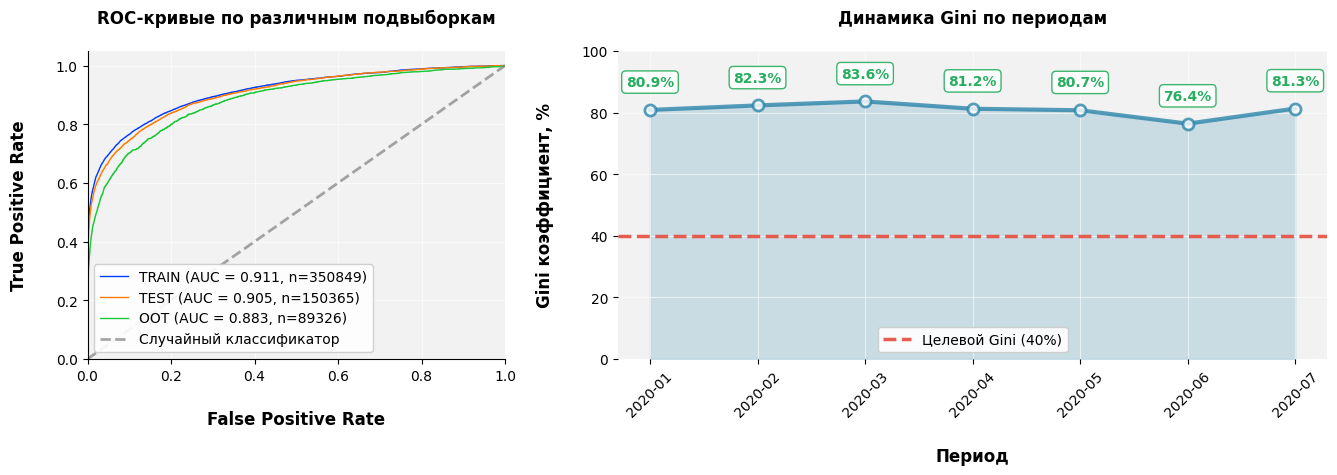

In [149]:
# Графики распределения таргета по выборкам
fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [1, 1.7]})
masks_dict = {'TRAIN': TRAIN_MASK, 'TEST': TEST_MASK, 'OOT': OOT_MASK}

ax = axes[0]
plot_roc_by_masks(data, TARGET, 'final_model_preds', masks_dict, 
                     figsize=(8, 4), palette='bright', 
                     title='ROC-кривые по различным подвыборкам',
                     ax=ax)

ax = axes[1]
plot_gini_by_period_styled(metr_split.reset_index(), 'gini', DATE_MONTH,
                              figsize=(8, 4), 
                              target_gini=40,
                              title='Динамика Gini по периодам',
                              ax=ax)

# Сохранение модели

In [150]:
final_model.save_model(r'./models/final_model.cbm')
joblib.dump(pipeline, r'./models/pipeline.joblib')

['./models/pipeline.joblib']

# SHAP переменных

In [151]:
# Создаем explainer
explainer = shap.TreeExplainer(final_model)

# Вычисляем SHAP значения для разных выборок
shap_cb_train = explainer(
    dev_sample.loc[TRAIN_MASK, FINAL_FEATURES],
    dev_sample.loc[TRAIN_MASK, TARGET]
)

shap_cb_test = explainer(
    dev_sample.loc[TEST_MASK, FINAL_FEATURES],
    dev_sample.loc[TEST_MASK, TARGET]
)

shap_cb_oot = explainer(
    dev_sample.loc[OOT_MASK, FINAL_FEATURES],
    dev_sample.loc[OOT_MASK, TARGET]
)

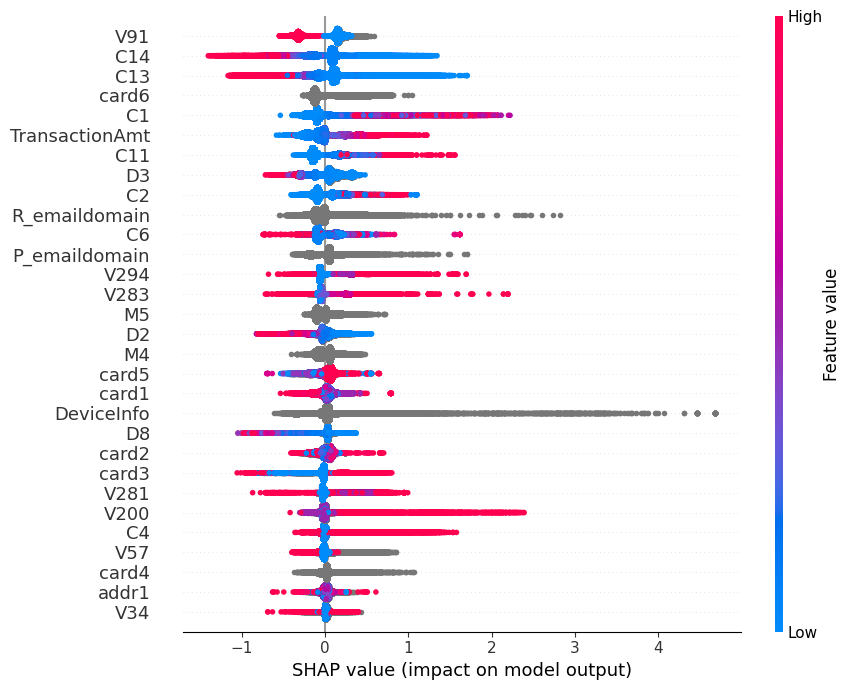

In [152]:
# Создаем summary plot
shap.summary_plot(
    shap_cb_test,
    dev_sample.loc[TEST_MASK, FINAL_FEATURES],
    feature_names=FINAL_FEATURES,
    plot_type="dot",
    max_display=len(FINAL_FEATURES),
    plot_size=(9, 7),
    show=False
)

# Сохраняем график
# path = r"reports/plots/shap.png"
# plt.savefig(path, bbox_inches="tight", pad_inches=0.1)

# Сравнение моделей

In [187]:
# время обучения в секундах
train_timing


{'Random_Forest': 244.42780804634094,
 'lgbm': 15.854280233383179,
 'xgboost': 49.693317890167236,
 'Catboost': 9.366055965423584}

In [213]:
#  сравнение по ROC-AUC score
pd.concat([roc_auc_rf, roc_auc_lgbm, roc_auc_xgboost, roc_auc_catboost], axis = 1,
           keys = ['rf', 'lgbm', 'xgboost', 'catboost'] )

,rf,lgbm,xgboost,catboost
sample_type,,,,
TRAIN,0.99,0.98,0.99,0.91
TEST,0.94,0.95,0.94,0.90
OOT,0.91,0.91,0.91,0.88


In [214]:
#  сравнение по recall
pd.concat([recall_rf, recall_lgbm, recall_xgboost, recall_catboost], axis = 1,
           keys = ['rf', 'lgbm', 'xgboost', 'catboost'] )

,rf,lgbm,xgboost,catboost
sample_type,,,,
TRAIN,0.84,0.64,0.84,0.41
TEST,0.60,0.54,0.60,0.39
OOT,0.46,0.38,0.46,0.31


In [ ]:
#  сравнение по precision
pd.concat([precision_rf, precision_lgbm, precision_xgboost, precision_catboost], axis = 1,
           keys = ['rf', 'lgbm', 'xgboost', 'catboost'] )

,rf,lgbm,xgboost,catboost
sample_type,,,,
TRAIN,0.76,0.95,0.76,0.92
TEST,0.65,0.89,0.65,0.90
OOT,0.58,0.76,0.58,0.81
